<a href="https://colab.research.google.com/github/samarsalem19/FDS/blob/main/Notebooks/Class%20Activities/Samar_Salem_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [1]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
from datascience import *
%matplotlib inline
path_data = '/content/drive/MyDrive/Colab Notebooks/Data Science /Class Activities/Iris.csv'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [3]:
# Load dataset

# Load the Iris dataset into a Table

# Read the CSV file using the Table class
iris = Table.read_table(path_data)

# Display the first few rows to verify that the data loaded correctly
iris.show(5)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [4]:
# Q1. How many rows and columns does the dataset have? Print the column names.

# Get the number of rows in the dataset
num_rows = iris.num_rows

# Get the number of columns in the dataset
num_columns = iris.num_columns

# Print the number of rows and columns
print("Number of rows:", num_rows)
print("Number of columns:", num_columns)

# Print the column names
print("Column names:", iris.labels)


Number of rows: 150
Number of columns: 6
Column names: ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [5]:
# Q2. How many flowers are there per species? Use the .group() method.

# Group the dataset by 'Species' and count the number of rows in each group
species_counts = iris.group('Species')

# Display the result
species_counts

Species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [6]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.

# Extract the columns from the table
petal_length = iris.column('PetalLengthCm')
petal_width = iris.column('PetalWidthCm')

# Compute statistics for PetalLengthCm using numpy
length_mean = np.mean(petal_length)
length_min = np.min(petal_length)
length_max = np.max(petal_length)

# Compute statistics for PetalWidthCm using numpy
width_mean = np.mean(petal_width)
width_min = np.min(petal_width)
width_max = np.max(petal_width)

# Print the results
print("Petal Length (cm):")
print("Mean:", length_mean)
print("Min:", length_min)
print("Max:", length_max)

print("\nPetal Width (cm):")
print("Mean:", width_mean)
print("Min:", width_min)
print("Max:", width_max)


Petal Length (cm):
Mean: 3.75866666667
Min: 1.0
Max: 6.9

Petal Width (cm):
Mean: 1.19866666667
Min: 0.1
Max: 2.5


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

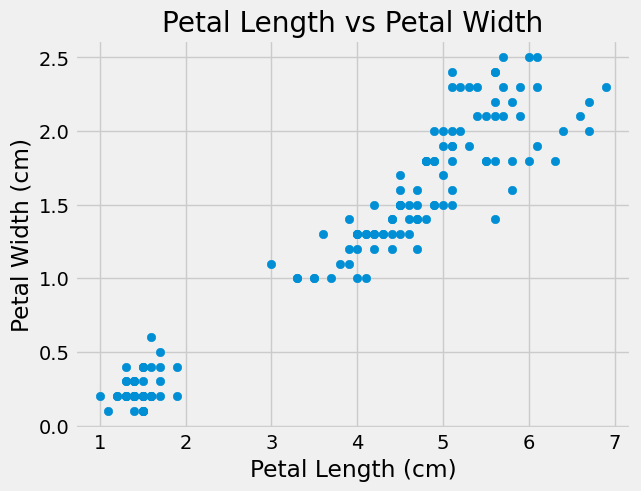

In [7]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.

# Scatter plot with PetalLengthCm (x-axis) and PetalWidthCm (y-axis)

# Extract columns
petal_length = iris.column('PetalLengthCm')
petal_width = iris.column('PetalWidthCm')

# Create scatter plot
plt.figure()  # ensures a fresh plot
plt.scatter(petal_length, petal_width)

# Labels and title
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")

# Show plot
plt.show()

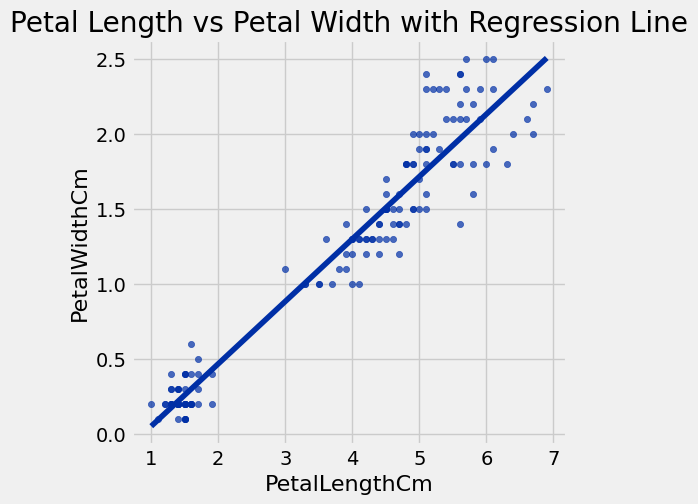

In [8]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.

# Create scatter plot with regression line
iris.scatter('PetalLengthCm', 'PetalWidthCm', fit_line=True)

# Add title to the plot
plt.title("Petal Length vs Petal Width with Regression Line")
plt.show()

# Explanation:
# The scatter plot shows a strong positive relationship between petal length and petal width.
# As petal length increases, petal width also increases, indicating a strong linear correlation.

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [9]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [10]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [11]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [12]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [18]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.

# Calculate slope
b1 = slope(iris, 'PetalLengthCm', 'PetalWidthCm')

# Calculate intercept
b0 = intercept(iris, 'PetalLengthCm', 'PetalWidthCm')

# Print results
print("Slope (b1):", b1)
print("Intercept (b0):", b0)

# Print full regression equation
print("\nRegression Equation:")
print("PetalWidthCm =", b0, "+", b1, "* PetalLengthCm")

Slope (b1): 0.416419132285
Intercept (b0): -0.366514045217

Regression Equation:
PetalWidthCm = -0.366514045217 + 0.416419132285 * PetalLengthCm


In [22]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.

# Given value
x = 4.5

# Use the regression equation
predicted_width = b0 + b1 * x

#  Calculation
print("Calculation:")
print("PetalWidthCm =", b0, "+", b1, "*", x)

# Result
print("\nPredicted Petal Width:", predicted_width)

Calculation:
PetalWidthCm = -0.366514045217 + 0.416419132285 * 4.5

Predicted Petal Width: 1.50737205007


In [26]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.

# Calculate correlation using the helper function
r = correlation(iris, 'PetalLengthCm', 'PetalWidthCm')

# Print the result
print("Correlation coefficient (r):", r)

# Explanation:
# The correlation coefficient is close to 1, indicating a strong positive relationship.
# This means that as petal length increases, petal width also increases significantly.
# Therefore, the relationship between the two variables is strong and positive.

Correlation coefficient (r): 0.962757097051


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [27]:
# Q9. Compute the predicted petal_width for every flower using your regression equation.
# Add both the predicted values and the residuals (actual - predicted) as new columns to the table.
# Display the first 8 rows.

# Extract columns
petal_length = iris.column('PetalLengthCm')
petal_width = iris.column('PetalWidthCm')

# Compute predicted values using regression equation: y = b0 + b1*x
predicted = b0 + b1 * petal_length

# Compute residuals: actual - predicted
residuals = petal_width - predicted

# Add new columns to the table
iris_with_predictions = iris.with_columns(
    "Predicted_PetalWidth", predicted,
    "Residual", residuals
)

# Display the first 8 rows
iris_with_predictions.show(8)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predicted_PetalWidth,Residual
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147


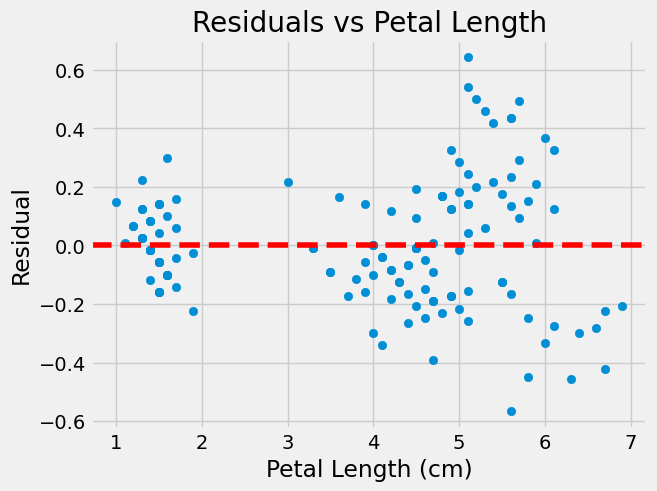

In [28]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis).
# Add a horizontal red dashed line at y = 0. In 2-3 sentences,
# interpret what this plot tells you about how well the linear model fits the data.


# Extract data
petal_length = iris_with_predictions.column('PetalLengthCm')
residuals = iris_with_predictions.column('Residual')

# Create scatter plot
plt.figure()
plt.scatter(petal_length, residuals)

# Add horizontal red dashed line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Labels and title
plt.xlabel("Petal Length (cm)")
plt.ylabel("Residual")
plt.title("Residuals vs Petal Length")

# Show plot
plt.show()


# Explanation:
# The residuals are randomly scattered around zero with small variation.
# This indicates that the linear model fits the data well.
# Therefore, there is a strong positive relationship between petal length and petal width.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.